In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder


In [ ]:
file_link = 'https://drive.google.com/file/d/1Nx9_APr9UjFBO0gUkh7HVCYPuFfCEdTp/view?usp=sharing'

id = file_link.split("/")[-2]

new_link = f'https://drive.google.com/uc?id={id}'
df = pd.read_csv(new_link)

df.head()

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
0,336867,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Winter 2014-15,12/01/2014,23.97,NaN
1,336741,375,Nitrogen dioxide (NO2),Mean,ppb,CD,107,Upper West Side (CD7),Winter 2014-15,12/01/2014,27.42,NaN
2,550157,375,Nitrogen dioxide (NO2),Mean,ppb,CD,414,Rockaway and Broad Channel (CD14),Annual Average 2017,01/01/2017,12.55,NaN
3,412802,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Winter 2015-16,12/01/2015,22.63,NaN
4,412803,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Summer 2016,06/01/2016,14.00,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18862 entries, 0 to 18861
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unique ID       18862 non-null  int64  
 1   Indicator ID    18862 non-null  int64  
 2   Name            18862 non-null  object 
 3   Measure         18862 non-null  object 
 4   Measure Info    18862 non-null  object 
 5   Geo Type Name   18862 non-null  object 
 6   Geo Join ID     18862 non-null  int64  
 7   Geo Place Name  18862 non-null  object 
 8   Time Period     18862 non-null  object 
 9   Start_Date      18862 non-null  object 
 10  Data Value      18862 non-null  float64
 11  Message         0 non-null      float64
dtypes: float64(2), int64(3), object(7)
memory usage: 1.7+ MB


In [ ]:
df.describe(include='all')

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
count,18862.000000,18862.000000,18862,18862,18862,18862,1.886200e+04,18862,18862,18862,18862.000000,0.0
unique,NaN,NaN,18,8,8,5,NaN,114,57,46,NaN,NaN
top,NaN,NaN,Nitrogen dioxide (NO2),Mean,ppb,UHF42,NaN,Williamsburg - Bushwick,2009-2011,01/01/2015,NaN,NaN
freq,NaN,NaN,6345,14805,8460,7392,NaN,281,480,906,NaN,NaN
mean,452004.167533,431.817888,NaN,NaN,NaN,NaN,5.983262e+05,NaN,NaN,NaN,21.051580,NaN
std,262910.731230,113.946565,NaN,NaN,NaN,NaN,7.819721e+06,NaN,NaN,NaN,23.564920,NaN
min,130355.000000,365.000000,NaN,NaN,NaN,NaN,1.000000e+00,NaN,NaN,NaN,0.000000,NaN
25%,176073.250000,365.000000,NaN,NaN,NaN,NaN,2.020000e+02,NaN,NaN,NaN,8.742004,NaN
50%,412490.500000,375.000000,NaN,NaN,NaN,NaN,3.030000e+02,NaN,NaN,NaN,14.790000,NaN
75%,669588.750000,386.000000,NaN,NaN,NaN,NaN,4.040000e+02,NaN,NaN,NaN,26.267500,NaN


In [ ]:
df.nunique()

,0
Unique ID,18862
Indicator ID,21
Name,18
Measure,8
Measure Info,8
Geo Type Name,5
Geo Join ID,72
Geo Place Name,114
Time Period,57
Start_Date,46


In [ ]:
df.isnull().sum()

,0
Unique ID,0
Indicator ID,0
Name,0
Measure,0
Measure Info,0
Geo Type Name,0
Geo Join ID,0
Geo Place Name,0
Time Period,0
Start_Date,0


In [ ]:
cat_cols=df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
['Name', 'Measure', 'Measure Info', 'Geo Type Name', 'Geo Place Name', 'Time Period', 'Start_Date']
Numerical Variables:
['Unique ID', 'Indicator ID', 'Geo Join ID', 'Data Value', 'Message']


Data Value
2.000000      46
5.000000      45
10.000000     41
9.000000      38
4.000000      36
              ..
210.400000     1
209.900000     1
232.600000     1
232.543986     1
228.600000     1
Name: count, Length: 7375, dtype: int64


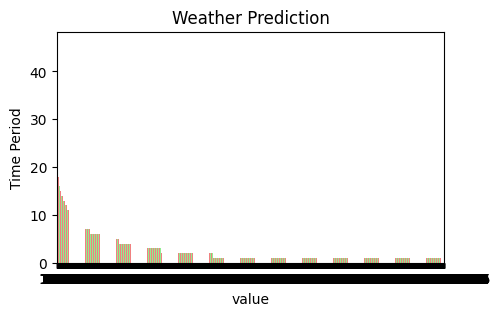

In [ ]:
print(df.value_counts('Data Value'))

plt.figure(figsize=(5, 3))
df['Data Value'].value_counts().plot(kind='bar', color=['lightcoral', 'lightgreen'])
plt.title('Weather Prediction')
plt.xlabel('value')
plt.ylabel('Time Period')
plt.xticks(rotation = 0)
plt.show()

In [ ]:
df.shape

(18862, 7)

In [ ]:
cat_cols=df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)


Categorical Variables:
['Name', 'Measure', 'Measure Info', 'Geo Type Name', 'Start_Date']
Numerical Variables:
['Geo Join ID', 'Data Value']


In [ ]:
def get_active_features(prefix):
    cols = [col for col in df.columns if col.startswith(prefix)]
    active = df[cols].idxmax(axis=1).str.replace(prefix, '')
    return active

#Decode One-Hot Encoded Columns
df['Pollutant'] = get_active_features('Name_')

# Measure
df['Measure'] = get_active_features('Measure_')

# Geo Type
df['Geo_Type'] = get_active_features('Geo Type Name_')

# Start Date (convert to datetime)
date_cols = [col for col in df.columns if col.startswith('Start_Date_')]
df['Date'] = pd.to_datetime(df[date_cols].idxmax(axis=1).str.replace('Start_Date_', ''))

#Drop Original One-Hot Columns
cols_to_drop = [col for col in df.columns if any(
    col.startswith(prefix)
    for prefix in ['Name_', 'Measure_', 'Geo Type Name_', 'Start_Date_']
)]
df = df.drop(cols_to_drop, axis=1)

#Keep Core Columns
final_cols = ['Geo Join ID', 'Data Value', 'Pollutant', 'Measure', 'Geo_Type', 'Date']
df = df[final_cols]

#Step 5: Extract Year/Month/Day
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df = df.drop('Date', axis=1)

print(df.head())

   Geo Join ID  Data Value               Pollutant Measure Geo_Type  Year  \
0          407       23.97  Nitrogen dioxide (NO2)    Mean       CD  2014   
1          107       27.42  Nitrogen dioxide (NO2)    Mean       CD  2014   
2          414       12.55  Nitrogen dioxide (NO2)    Mean       CD  2017   
3          407       22.63  Nitrogen dioxide (NO2)    Mean       CD  2015   
4          407       14.00  Nitrogen dioxide (NO2)    Mean       CD  2016   

   Month  Day  
0     12    1  
1     12    1  
2      1    1  
3     12    1  
4      6    1  


In [ ]:
print(df.dtypes)

Geo Join ID      int64
Data Value     float64
Pollutant       object
Measure         object
Geo_Type        object
Year             int32
Month            int32
Day              int32
dtype: object


In [ ]:
# Add 'Season' based on month
df['Season'] = df['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})

# Add 'Weekday' (0=Monday to 6=Sunday)
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])
df['Weekday'] = df['Date'].dt.dayofweek
df = df.drop('Date', axis=1)

In [ ]:
print("Your columns:", df.columns.tolist())

# Look for similar columns to 'Geo_Type' - maybe 'Geo Type Name' or similar
geo_type_col = None
for possible_col in ['Geo_Type', 'Geo Type Name', 'GeoType', 'Geography Type']:
    if possible_col in df.columns:
        geo_type_col = possible_col
        break

# If we found a geographic type column
if geo_type_col:
    le = LabelEncoder()
    df['Geo_Type_Encoded'] = le.fit_transform(df[geo_type_col])
    df = df.drop(geo_type_col, axis=1)
else:
    print("Warning: No geographic type column found")

# Similarly for season (if you have it)
if 'Season' in df.columns:
    le = LabelEncoder()
    df['Season_Encoded'] = le.fit_transform(df['Season'])
    df = df.drop('Season', axis=1)
else:
    print("Warning: No season column found")

print(df.head())

Your columns: ['Geo Join ID', 'Data Value', 'Pollutant', 'Measure', 'Year', 'Month', 'Day', 'Weekday', 'Geo_Type_Encoded', 'Season_Encoded']
   Geo Join ID  Data Value               Pollutant Measure  Year  Month  Day  \
0          407       23.97  Nitrogen dioxide (NO2)    Mean  2014     12    1   
1          107       27.42  Nitrogen dioxide (NO2)    Mean  2014     12    1   
2          414       12.55  Nitrogen dioxide (NO2)    Mean  2017      1    1   
3          407       22.63  Nitrogen dioxide (NO2)    Mean  2015     12    1   
4          407       14.00  Nitrogen dioxide (NO2)    Mean  2016      6    1   

   Weekday  Geo_Type_Encoded  Season_Encoded  
0        0                 1               1  
1        0                 1               1  
2        6                 1               1  
3        1                 1               1  
4        2                 1               0  


In [ ]:
print(df.isnull().sum())

Geo Join ID         0
Data Value          0
Pollutant           0
Measure             0
Year                0
Month               0
Day                 0
Weekday             0
Geo_Type_Encoded    0
Season_Encoded      0
dtype: int64


In [ ]:
print("Current columns:", df.columns.tolist())

Current columns: ['Geo Join ID', 'Data Value', 'Pollutant', 'Measure', 'Year', 'Month', 'Day', 'Weekday', 'Geo_Type_Encoded', 'Season_Encoded']


In [ ]:
print(df.head())

   Geo Join ID  Data Value               Pollutant Measure  Year  Month  Day  \
0          407       23.97  Nitrogen dioxide (NO2)    Mean  2014     12    1   
1          107       27.42  Nitrogen dioxide (NO2)    Mean  2014     12    1   
2          414       12.55  Nitrogen dioxide (NO2)    Mean  2017      1    1   
3          407       22.63  Nitrogen dioxide (NO2)    Mean  2015     12    1   
4          407       14.00  Nitrogen dioxide (NO2)    Mean  2016      6    1   

   Weekday  Geo_Type_Encoded  Season_Encoded  
0        0                 1               1  
1        0                 1               1  
2        6                 1               1  
3        1                 1               1  
4        2                 1               0  


In [ ]:
# For Month (12-month cycle)
df['Month_sin'] = np.sin(2 * np.pi * df['Month']/12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month']/12)

# For Weekday (7-day cycle)
df['Weekday_sin'] = np.sin(2 * np.pi * df['Weekday']/7)
df['Weekday_cos'] = np.cos(2 * np.pi * df['Weekday']/7)

   Geo Join ID  Data Value               Pollutant Measure  Year  Month  Day  \
0          407       23.97  Nitrogen dioxide (NO2)    Mean  2014     12    1   
1          107       27.42  Nitrogen dioxide (NO2)    Mean  2014     12    1   
2          414       12.55  Nitrogen dioxide (NO2)    Mean  2017      1    1   
3          407       22.63  Nitrogen dioxide (NO2)    Mean  2015     12    1   
4          407       14.00  Nitrogen dioxide (NO2)    Mean  2016      6    1   

   Weekday  Geo_Type_Encoded  Season_Encoded     Month_sin  Month_cos  \
0        0                 1               1 -2.449294e-16   1.000000   
1        0                 1               1 -2.449294e-16   1.000000   
2        6                 1               1  5.000000e-01   0.866025   
3        1                 1               1 -2.449294e-16   1.000000   
4        2                 1               0  1.224647e-16  -1.000000   

   Weekday_sin  Weekday_cos  
0     0.000000     1.000000  
1     0.000000     1

In [ ]:
# Target encode 'Pollutant' (analyzing multiple pollutants)
if df['Pollutant'].nunique() > 1:
    pollutant_avg = df.groupby('Pollutant')['Data Value'].mean().to_dict()
    df['Pollutant_Encoded'] = df['Pollutant'].map(pollutant_avg)

# One-hot encode 'Measure'
if df['Measure'].nunique() < 10:
    df = pd.get_dummies(df, columns=['Measure'], prefix='Measure')

In [ ]:
print(df.head())

   Geo Join ID  Data Value               Pollutant  Year  Month  Day  Weekday  \
0          407       23.97  Nitrogen dioxide (NO2)  2014     12    1        0   
1          107       27.42  Nitrogen dioxide (NO2)  2014     12    1        0   
2          414       12.55  Nitrogen dioxide (NO2)  2017      1    1        6   
3          407       22.63  Nitrogen dioxide (NO2)  2015     12    1        1   
4          407       14.00  Nitrogen dioxide (NO2)  2016      6    1        2   

   Geo_Type_Encoded  Season_Encoded     Month_sin  ...  Weekday_cos  \
0                 1               1 -2.449294e-16  ...     1.000000   
1                 1               1 -2.449294e-16  ...     1.000000   
2                 1               1  5.000000e-01  ...     0.623490   
3                 1               1 -2.449294e-16  ...     0.623490   
4                 1               0  1.224647e-16  ...    -0.222521   

   Pollutant_Encoded  Measure_Annual average concentration  \
0          20.391861    

In [ ]:
unique_pollutants = df['Pollutant'].nunique()
print(f"Number of unique pollutants: {unique_pollutants}")

Number of unique pollutants: 18


In [ ]:
print(df['Pollutant'].value_counts())

Pollutant
Nitrogen dioxide (NO2)                                    6345
Fine particles (PM 2.5)                                   6345
Ozone (O3)                                                2115
Asthma emergency department visits due to PM2.5            480
Asthma hospitalizations due to Ozone                       480
Asthma emergency departments visits due to Ozone           480
Annual vehicle miles traveled (cars)                       321
Annual vehicle miles traveled (trucks)                     321
Annual vehicle miles traveled                              321
Respiratory hospitalizations due to PM2.5 (age 20+)        240
Deaths due to PM2.5                                        240
Cardiac and respiratory deaths due to Ozone                240
Cardiovascular hospitalizations due to PM2.5 (age 40+)     240
Outdoor Air Toxics - Formaldehyde                          203
Outdoor Air Toxics - Benzene                               203
Boiler Emissions- Total PM2.5 Emissions      

In [ ]:
# Primary pollutants (keep as features)
pollutants = ['Nitrogen dioxide (NO2)', 'Fine particles (PM 2.5)', 'Ozone (O3)']

# Health outcomes (use as targets or drop)
health_targets = [
    'Asthma emergency department visits due to PM2.5',
    'Cardiac and respiratory deaths due to Ozone',

]

# Low-frequency metrics (drop or aggregate)
low_freq = [
    'Annual vehicle miles traveled',
    'Outdoor Air Toxics - Formaldehyde',

]

# Filter dataframe
df_pollutants = df[df['Pollutant'].isin(pollutants)]

In [ ]:
# Recalculate Pollutant_Encoded (NO₂/PM2.5/O₃ only)
df_pollutants['Pollutant_Encoded'] = df_pollutants.groupby('Pollutant')['Data Value'].transform('mean')

# Verify
print(df_pollutants.groupby('Pollutant')['Pollutant_Encoded'].mean())

Pollutant
Fine particles (PM 2.5)     9.045471
Nitrogen dioxide (NO2)     20.391861
Ozone (O3)                 30.782266
Name: Pollutant_Encoded, dtype: float64


/tmp/ipython-input-1232530910.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pollutants['Pollutant_Encoded'] = df_pollutants.groupby('Pollutant')['Data Value'].transform('mean')


In [ ]:
df['Pollutant'] = df['Pollutant'].apply(
    lambda x: 'Health Outcome' if x in health_targets else (
        'Emissions' if 'Boiler Emissions' in x else x
    )
)

In [ ]:
# Pivot primary pollutants into columns
df_wide = df_pollutants.pivot_table(
    index=['Geo Join ID', 'Year', 'Month', 'Day'],
    columns='Pollutant',
    values=['Data Value', 'Pollutant_Encoded']
).reset_index()

# Flatten multi-index columns
df_wide.columns = ['_'.join(col).strip() for col in df_wide.columns]

In [ ]:
df.describe(include='all')

,Geo Join ID,Data Value,Pollutant,Year,Month,Day,Weekday,Geo_Type_Encoded,Season_Encoded,Month_sin,...,Weekday_cos,Pollutant_Encoded,Measure_Annual average concentration,Measure_Estimated annual rate,Measure_Estimated annual rate (age 18+),Measure_Estimated annual rate (age 30+),Measure_Estimated annual rate (under age 18),Measure_Mean,Measure_Million miles,Measure_Number per km2
count,1.886200e+04,18862.000000,18862,18862.000000,18862.000000,18862.000000,18862.000000,18862.000000,18862.000000,1.886200e+04,...,18862.000000,18862.000000,18862,18862,18862,18862,18862,18862,18862,18862
unique,NaN,NaN,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2,2,2,2,2,2,2,2
top,NaN,NaN,Nitrogen dioxide (NO2),NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,False,False,False,False,False,True,False,False
freq,NaN,NaN,6345,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,18456,18142,18142,18622,18142,14805,17899,18574
mean,5.983262e+05,21.051580,NaN,2014.719542,6.300021,1.473969,2.908493,2.516912,0.663609,1.673470e-01,...,-0.003525,21.051580,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,7.819721e+06,23.564920,NaN,4.770222,4.485461,3.641034,1.980768,1.428020,0.472487,2.359480e-01,...,0.708638,17.172270,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000e+00,0.000000,NaN,2005.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-2.449294e-16,...,-0.900969,1.373958,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2.020000e+02,8.742004,NaN,2011.000000,1.000000,1.000000,1.000000,1.000000,0.000000,-2.449294e-16,...,-0.900969,9.045471,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,3.030000e+02,14.790000,NaN,2015.000000,6.000000,1.000000,3.000000,3.000000,1.000000,1.224647e-16,...,-0.222521,20.391861,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,4.040000e+02,26.267500,NaN,2019.000000,12.000000,1.000000,5.000000,4.000000,1.000000,5.000000e-01,...,0.623490,20.391861,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Current columns:", df.columns.tolist())

Current columns: ['Geo Join ID', 'Data Value', 'Pollutant', 'Year', 'Month', 'Day', 'Weekday', 'Geo_Type_Encoded', 'Season_Encoded', 'Month_sin', 'Month_cos', 'Weekday_sin', 'Weekday_cos', 'Pollutant_Encoded', 'Measure_Annual average concentration', 'Measure_Estimated annual rate', 'Measure_Estimated annual rate (age 18+)', 'Measure_Estimated annual rate (age 30+)', 'Measure_Estimated annual rate (under age 18)', 'Measure_Mean', 'Measure_Million miles', 'Measure_Number per km2']


In [ ]:
df['Pollution_Level'] = np.where(df['Data Value'] > df['Data Value'].median(), 'High', 'Low')

le = LabelEncoder()
df['Pollution_Level_Encoded'] = le.fit_transform(df['Pollution_Level'])

features = [
    'Pollutant_Encoded',
    'Year',
    'Month_sin', 'Month_cos',
    'Weekday_sin', 'Weekday_cos',
    'Geo_Type_Encoded',
    'Season_Encoded',
    'Measure_Mean'
]

X = df[features]
y = df['Pollution_Level_Encoded']


split_year = 2020
X_train = X[df['Year'] < split_year]
X_test = X[df['Year'] >= split_year]
y_train = y[df['Year'] < split_year]
y_test = y[df['Year'] >= split_year]


X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())

ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=5),
    n_estimators=100,
    learning_rate=0.8,
    random_state=42
)

ada_model.fit(X_train, y_train)
y_pred = ada_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, ada_model.predict(X_test)))

Accuracy: 0.84
              precision    recall  f1-score   support

           0       0.72      1.00      0.84      1521
           1       1.00      0.73      0.84      2145

    accuracy                           0.84      3666
   macro avg       0.86      0.86      0.84      3666
weighted avg       0.88      0.84      0.84      3666

